<a href="https://colab.research.google.com/github/Omprakash9805/TECH-405/blob/main/Plant%20Disease%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATASET_PATH = "PlantVillage"      # Change this path

train_path = os.path.join(DATASET_PATH, "train")
valid_path = os.path.join(DATASET_PATH, "valid")
test_path  = os.path.join(DATASET_PATH, "test")

In [15]:
!pip install -q kaggle

In [17]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [19]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:34<00:00, 84.0MB/s]



In [21]:
import os

os.listdir("dataset")

['New Plant Diseases Dataset(Augmented)']

In [22]:
import os

train_path = os.path.join(
    "dataset",
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

classes = sorted([
    folder
    for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 26
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


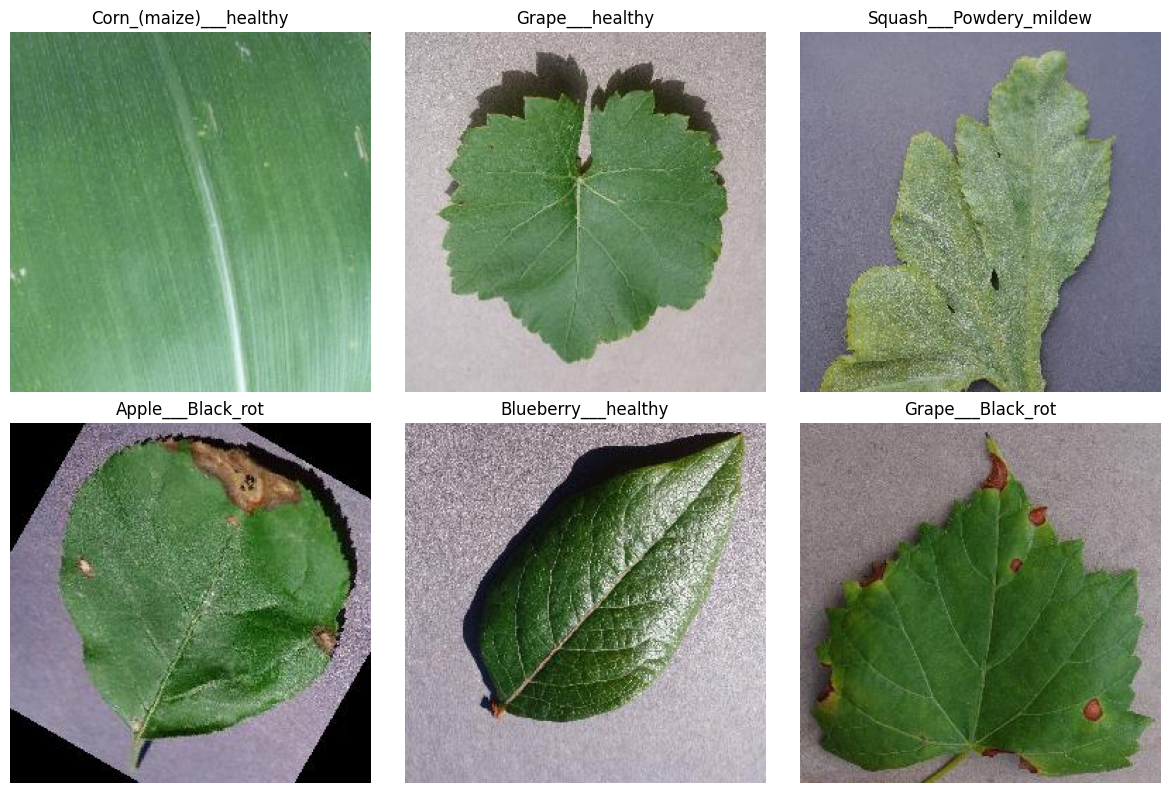

In [23]:
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i in range(6):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img = Image.open(os.path.join(train_path, cls, img_name))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
classes = sorted(os.listdir(train_path))

print("Number of Classes:", len(classes))

Number of Classes: 26


In [25]:
for i, c in enumerate(classes):
    print(i+1, c)

1 Apple___Apple_scab
2 Apple___Black_rot
3 Apple___Cedar_apple_rust
4 Apple___healthy
5 Blueberry___healthy
6 Cherry_(including_sour)___Powdery_mildew
7 Cherry_(including_sour)___healthy
8 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9 Corn_(maize)___Common_rust_
10 Corn_(maize)___Northern_Leaf_Blight
11 Corn_(maize)___healthy
12 Grape___Black_rot
13 Grape___Esca_(Black_Measles)
14 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15 Grape___healthy
16 Orange___Haunglongbing_(Citrus_greening)
17 Peach___Bacterial_spot
18 Peach___healthy
19 Pepper,_bell___Bacterial_spot
20 Pepper,_bell___healthy
21 Potato___Early_blight
22 Potato___Late_blight
23 Potato___healthy
24 Raspberry___healthy
25 Soybean___healthy
26 Squash___Powdery_mildew


In [26]:
image_count = {}

for folder in classes:
    folder_path = os.path.join(train_path, folder)
    image_count[folder] = len(os.listdir(folder_path))

df = pd.DataFrame({
    "Class": image_count.keys(),
    "Images": image_count.values()
})

df.head()

,Class,Images
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816


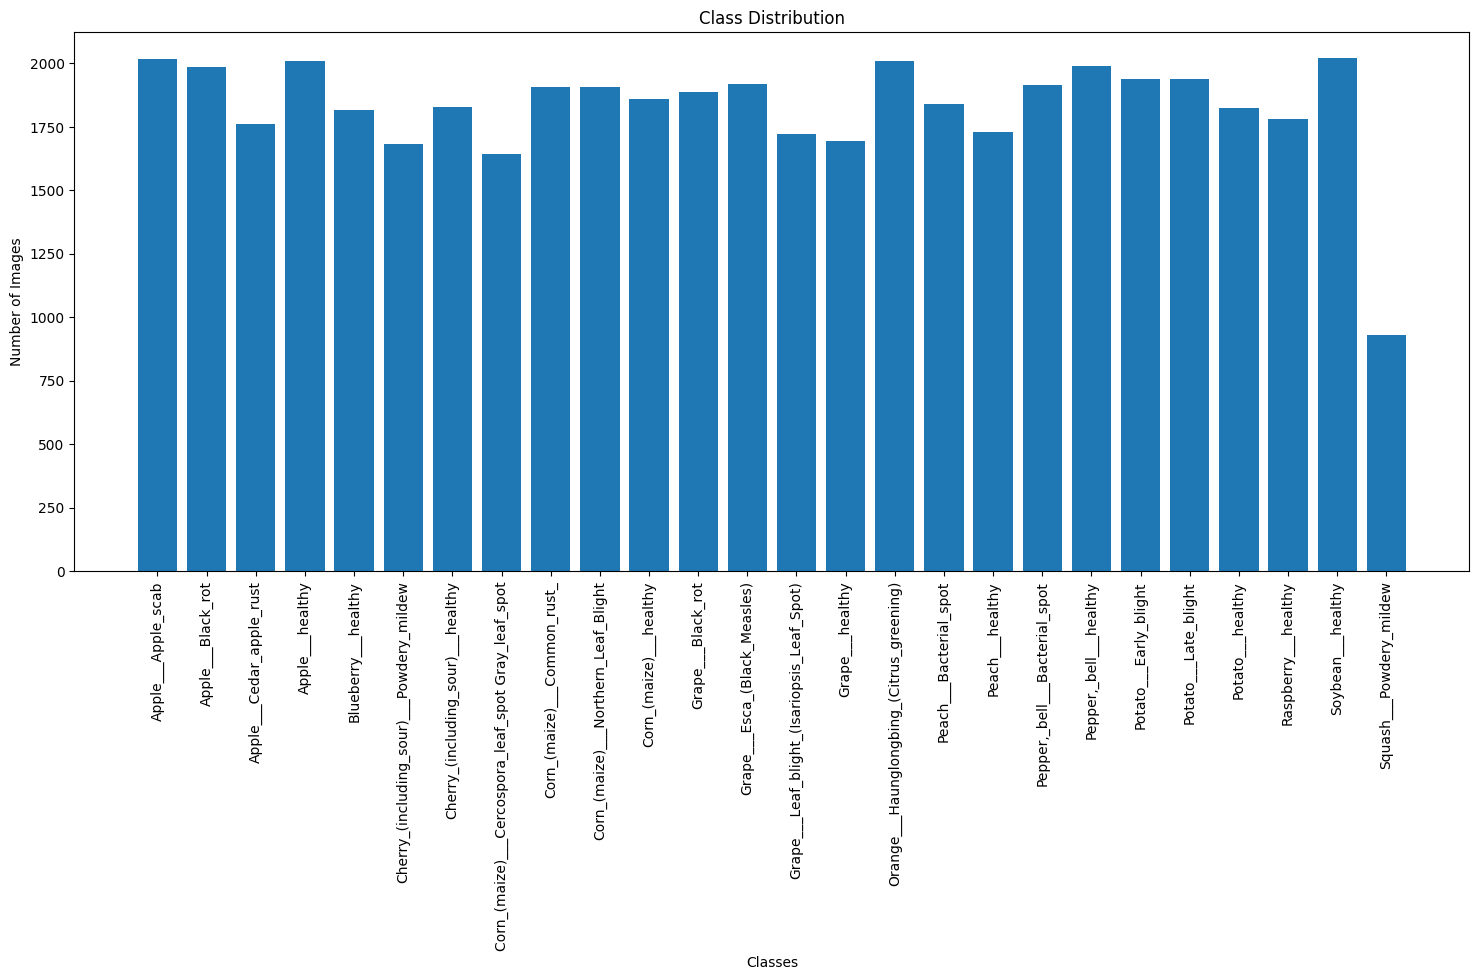

In [27]:
plt.figure(figsize=(18,7))

plt.bar(df["Class"], df["Images"])

plt.xticks(rotation=90)

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

In [28]:
print("Total Images:", df["Images"].sum())

Total Images: 47547


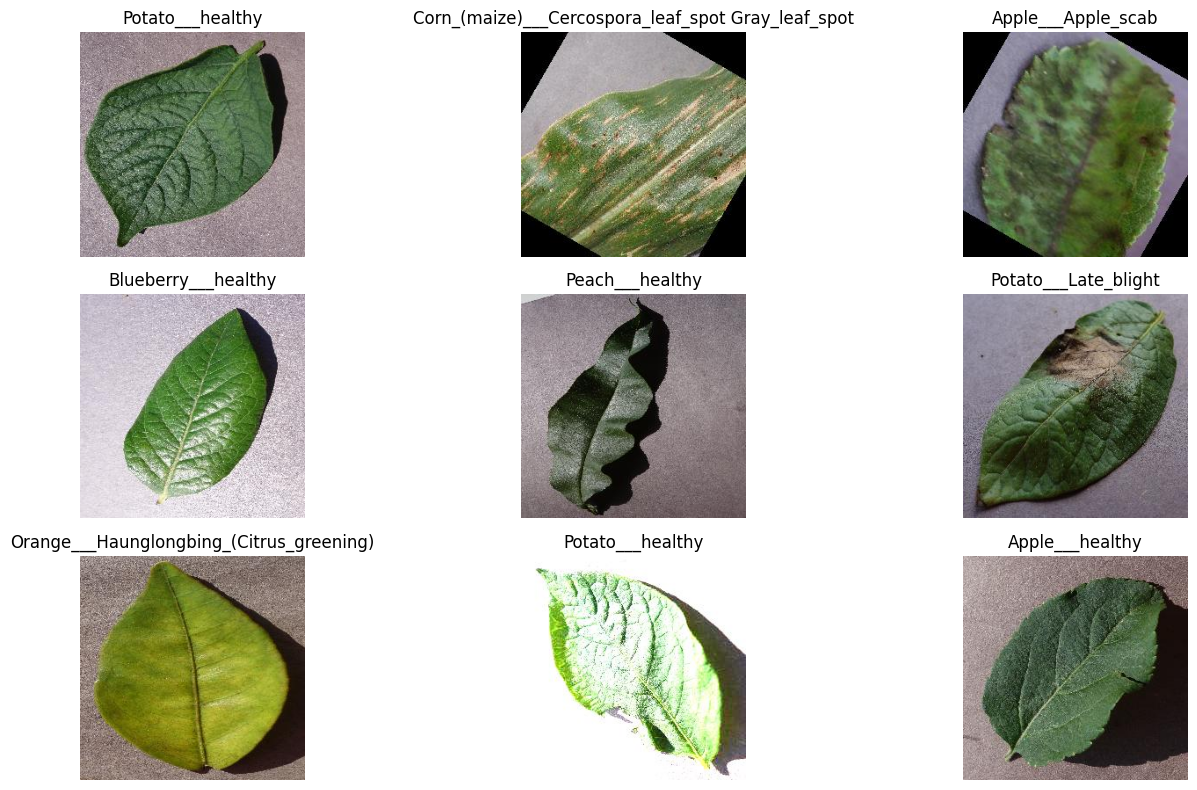

In [29]:
plt.figure(figsize=(15,8))

for i in range(9):

    folder = random.choice(classes)

    image = random.choice(
        os.listdir(os.path.join(train_path, folder))
    )

    img = Image.open(
        os.path.join(train_path, folder, image)
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(folder)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [30]:
width = []
height = []

for folder in classes:

    folder_path = os.path.join(train_path, folder)

    for image in os.listdir(folder_path):

        img = Image.open(
            os.path.join(folder_path,image)
        )

        w,h = img.size

        width.append(w)

        height.append(h)

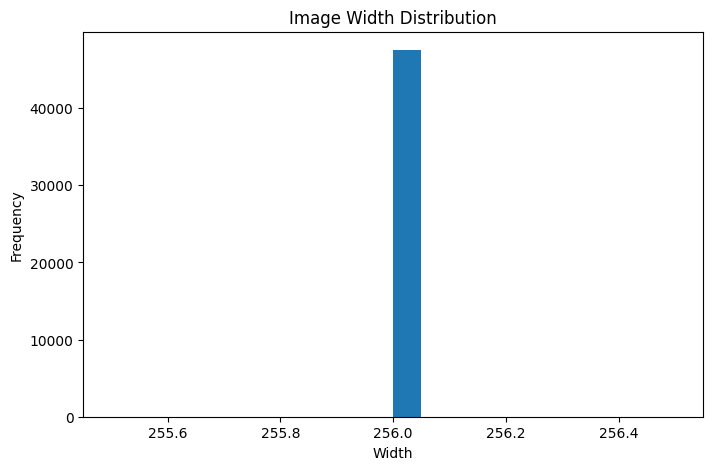

In [31]:
plt.figure(figsize=(8,5))

plt.hist(width,bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

In [33]:
print("Average Width :", np.mean(width))

print("Average Height:", np.mean(height))

print("Minimum Width :", min(width))

print("Maximum Width :", max(width))

Average Width : 256.0
Average Height: 256.0
Minimum Width : 256
Maximum Width : 256


In [34]:
pixels = []

for folder in classes[:3]:

    folder_path = os.path.join(train_path,folder)

    imgs = os.listdir(folder_path)[:50]

    for image in imgs:

        img = Image.open(
            os.path.join(folder_path,image)
        ).convert("RGB")

        img = np.array(img)

        pixels.extend(img.reshape(-1,3))

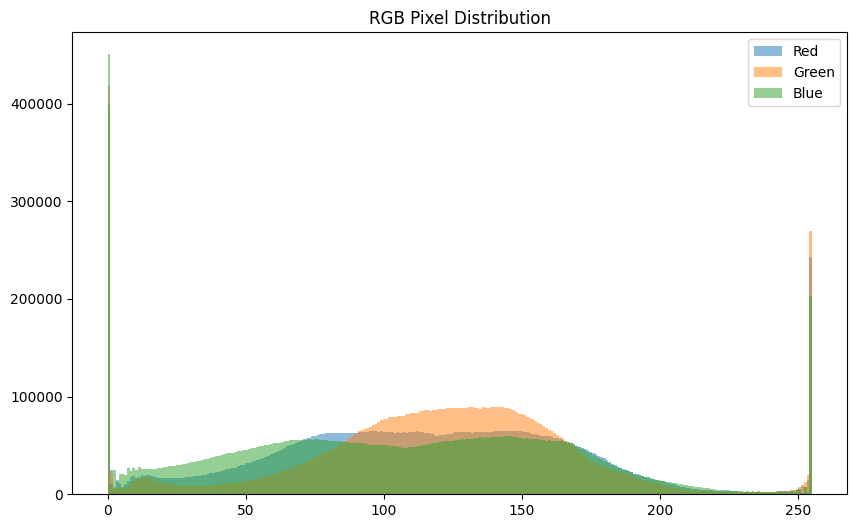

In [35]:
pixels = np.array(pixels)

plt.figure(figsize=(10,6))

plt.hist(pixels[:,0],bins=256,alpha=0.5,label="Red")

plt.hist(pixels[:,1],bins=256,alpha=0.5,label="Green")

plt.hist(pixels[:,2],bins=256,alpha=0.5,label="Blue")

plt.legend()

plt.title("RGB Pixel Distribution")

plt.show()

In [36]:
resolution = []

for folder in classes:

    folder_path = os.path.join(train_path,folder)

    for image in os.listdir(folder_path):

        img = Image.open(
            os.path.join(folder_path,image)
        )

        resolution.append(img.size)

Counter(resolution)

Counter({(256, 256): 47547})

In [37]:
encoder = LabelEncoder()

encoded = encoder.fit_transform(classes)

pd.DataFrame({
    "Class":classes,
    "Encoded":encoded
})

,Class,Encoded
0,Apple___Apple_scab,0
1,Apple___Black_rot,1
2,Apple___Cedar_apple_rust,2
3,Apple___healthy,3
4,Blueberry___healthy,4
5,Cherry_(including_sour)___Powdery_mildew,5
6,Cherry_(including_sour)___healthy,6
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,7
8,Corn_(maize)___Common_rust_,8
9,Corn_(maize)___Northern_Leaf_Blight,9


Original Size: (256, 256)
Resized: (224, 224)


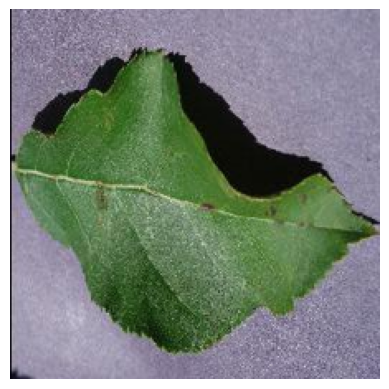

In [38]:
img = Image.open(
    os.path.join(
        train_path,
        classes[0],
        os.listdir(
            os.path.join(train_path,classes[0])
        )[0]
    )
)

print("Original Size:",img.size)

img = img.resize((224,224))

print("Resized:",img.size)

plt.imshow(img)

plt.axis("off")

plt.show()

In [39]:
img = np.array(img)

img = img / 255.0

print(img.min())

print(img.max())

0.0
0.9098039215686274


In [40]:
summary = pd.DataFrame({

    "Total Classes":[len(classes)],

    "Total Images":[df["Images"].sum()],

    "Average Width":[np.mean(width)],

    "Average Height":[np.mean(height)]

})

summary

,Total Classes,Total Images,Average Width,Average Height
0,26,47547,256.0,256.0


#baKGZOhip[
  